### Fidelity calculations

In [1]:
import numpy as np
import math

def omega_q_even(N, q, k1, k2, phi, t):
  """
  Calculates Omega_q^{(j)} for even j in Eq. (2).

  Args:
      q: Mode index.
      k1: k_(j-1) value.
      k2: k_(j+1) value.
      phi: Phase factor.

  Returns:
      Value of Omega_q^{(j)}.
  """
  alpha = (k2 - k1)*t + phi
  return 1j**(N-q) * np.exp(1j * N * alpha / 2) * np.sqrt(math.comb(N,q)) * (np.cos(alpha/2)**q) * (np.sin(alpha/2)**(N-q))


def omega_q_odd(N, q, k, phi):
  """
  Calculates Omega_q^{(j)} for odd j

  Args:
      q: Mode index.
      k: k_j value.
      phi: Phase factor.
      N: Number of bosons

  Returns:
      Value of Omega_q^{(j)}.
  """  

  result = 0
  for l in range(q + 1):
    for m in range(N - q + 1):
      # Kronecker delta check using np.where
      # delta_lm_k = np.where(k == l + m)[0]
      if  k != l+m:  # Check if k matches any sum of l and m
        result += math.comb(q,l) * math.comb(N-q,m) * ((-1) ** (N - q - m)) * np.sqrt(math.factorial(l + m) * math.factorial(N - l - m)) 
  return np.exp(1j * k * phi) * np.sqrt(math.comb(N,k)) * result / np.sqrt(math.factorial(q) * math.factorial(N - q) * (2 ** N))


# def fidelity(N, M, q, phi, k_list, C_N):
#   """
#   Calculates the fidelity F

#   Args:
#       N: Number of qubits.
#       M: Number of modes.
#       q: Specific mode index.
#       phi: Phase factor.
#       k_list: List of k_j values.
#       C_N: Binomial coefficient function (e.g., np.math.comb).

#   Returns:
#       Fidelity value.
#   """
#   even_terms = []
#   odd_terms = []
#   for i in range(2, M):
#     if i % 2 == 0:
#       # Even term
#       even_terms.append(omega_q_even(q, k_list[i-1], k_list[i+1], phi))
#     else:
#       # Odd term
#       odd_terms.append(omega_q_odd(q, k_list[i], phi, C_N))

#   # Combine terms and calculate magnitude squared
#   combined_term = np.sum(even_terms * odd_terms)
#   result = np.abs(combined_term)**2

#   # Pre-factor
#   result *= (1 / (2**(N * (M+2) / 2))) * np.product(np.cos(0.5 * (k_list[0] - k_list[-1]) * np.pi / N)**N)**2

#   return result



In [2]:
#### Fidelity M=3

def fidelity3(N, q, phi, t):
  """
  Calculates the fidelity F

  Args:
      N: Number of qubits.      
      q: Specific mode index.
      phi: Phase factor.
      

  Returns:
      Fidelity value.
  """
  result = 0
  for k1 in range(N+1):
    for k3 in range(N+1):
      result += math.comb(N,k1)*math.comb(N,k3)*omega_q_even(N, q, k1, k3, phi, t)*np.exp(-1j*k1*k3*t)
  return (np.abs(result)**2)/(2**(4*N))
      


In [3]:
#### Fidelity M=4

def fidelity4(N, q, phi, t):
  """
  Calculates the fidelity F

  Args:
      N: Number of qubits.      
      q: Specific mode index.
      phi: Phase factor.
      

  Returns:
      Fidelity value.
  """
  result = 0
  for k1 in range(N+1):
    for k3 in range(N+1):
      result += math.comb(N,k1)*omega_q_even(N, q, k1, k3, phi, t)*omega_q_odd(N, q, k3, phi)*(np.cos((k1-k3)*t/2)**N)
  return (np.abs(result)**2)/(2**(3*N))
      


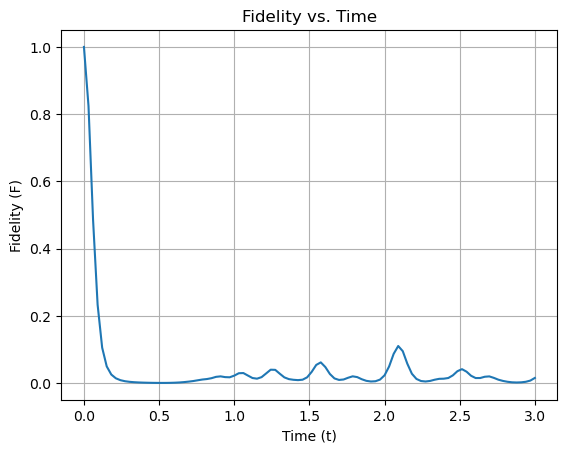

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fidelity(N, q, phi, t_range, title="Fidelity vs. Time"):
  """
  Plots the fidelity F versus time t for a given measurement result.

  """
  t_vals = np.linspace(t_range[0], t_range[1], 100)  # Adjust number of points as needed
  fidelity_vals = []
  for t in t_vals:
    fidelity_vals.append(fidelity4(N, q, phi, t))

  plt.plot(t_vals, fidelity_vals/np.max(fidelity_vals))
  plt.xlabel("Time (t)")
  plt.ylabel("Fidelity (F)")
  plt.title(title)
  plt.grid(True)
  plt.show()


N = 10

q = 10
phi = 0

t_range = (0, 3)  # Time range for the plot

plot_fidelity(N, q, phi, t_range)


### SzSz Fidelity calculations

In [33]:
def omega_q_zz(N, k1, q, k2, t):
  """
  Calculates Omega_q^{(j)} for even j in Eq. (2).

  """
  alpha = (2*N - 2*k2 - 2*k1)*t
  return np.sqrt(math.comb(N,q)) * (np.cos(alpha)**q) * (np.sin(alpha)**(N-q))


def pkx(N, p, k):
  """
  Calculates Omega_q^{(j)} for odd j

  
  """  

  result = 0
  for l in range(k + 1):
    for m in range(N - k + 1):      
      if l+m != p:  # Check if k matches any sum of l and m
        result += math.comb(k,l) * math.comb(N-k,m) * ((-1) ** (N - k - m)) * np.sqrt(math.factorial(l + m) * math.factorial(N - l - m)) 
  return result / np.sqrt(math.factorial(k) * math.factorial(N - k) * (2 ** N))


In [49]:
#### Fidelity M=3

def fidelity3zz(N, q, t):
  """
  Calculates the fidelity F

  
  """
  result = 0
  for k1 in range(N+1):
    for k3 in range(N+1):
      result += math.comb(N,k1)*math.comb(N,k3)*omega_q_zz(N, k1, q, k3, t)*np.exp(1j*(N-2*k1)*(N-2*k3)*t)
  return np.abs(result)/(2**(2*N))
      

def norm3zz(N, q, t):
  """
  Calculates the fidelity F

  
  """
  result = 0
  for k1 in range(N+1):
    for k3 in range(N+1):
      alpha = (2*N - 2*k3 - 2*k1)*t
      result += math.comb(N,k1)*math.comb(N,k3)*omega_q_zz(N, k1, q, k3, t)*((np.cos(alpha)**q) * (np.sin(alpha)**(N-q)))**2
  return np.sqrt(math.comb(N,q)*result)/(2**N)

In [71]:
#### Fidelity M=4

def fidelity4zz(N, q, t):
  """
  Calculates the fidelity F

  
  """
  result = 0
  for k1 in range(N+1):
    for k3 in range(N+1):
      if k3 != 0 and k3 != N:      
        result += math.comb(N,k1)*np.sqrt(math.comb(N,k3))*omega_q_zz(N, k1, q, k3, t)*(np.cos((2*k3-2*k1)*t)**N)*pkx(N,q,k3)
      else:
        result += math.comb(N,k1)*np.sqrt(math.comb(N,k3))*omega_q_zz(N, k1, q, k3, t)*(np.cos((2*k3-2*k1)*t)**N)#*pkx(N,q,k3)      
  return np.abs(result)/(2**(1.5*N))
      

# def norm4zz(N, q, t):
#   """
#   Calculates the norm

  
#   """
#   result = 0
#   for k1 in range(N+1):
#     for k3 in range(N+1):
#       for k33 in range(N+1):        
#         result += math.comb(N,k1)*np.sqrt(math.comb(N,k3)*math.comb(N,k33))*omega_q_zz(N, k1, q, k3, t)*pkx(N,q,k3)*np.conjugate(omega_q_zz(N, k1, q, k33, t))*pkx(N,q,k33)*(np.cos((2*k3-2*k33)*t)**N)
#   return np.sqrt(result)/(2**N)

In [72]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fidelity(N, q, t_range, title="Fidelity vs. Time"):
  """
  Plots the fidelity F versus time t for a given measurement result.

  """
  t_vals = np.linspace(t_range[0], t_range[1], 100)  # Adjust number of points as needed
  fidelity_vals = []
  for t in t_vals:
    fidelity_vals.append(fidelity4zz(N, q, t))#/norm4zz(N, q, t))

  plt.plot(t_vals, fidelity_vals)
  plt.xlabel("Time (t)")
  plt.ylabel("Fidelity (F)")
  plt.title(title)
  plt.grid(True)
  plt.show()


N = 20

q = 20


t_range = (0, 3)  # Time range for the plot

plot_fidelity(N, q, t_range)


TypeError: loop of ufunc does not support argument 0 of type int which has no callable sqrt method